<a href="https://colab.research.google.com/github/gowripreetham/SJSU_Deep_Learning_neural-network-using-numpy-keras-pytorch/blob/main/colab_c_pytorch_classes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab C — 3-Layer Neural Network: PyTorch Class-Based (nn.Module)

**Assignment:** Use PyTorch's OOP pattern — `nn.Module`, `nn.Linear`, `nn.ReLU`, and an `optimizer`.  
This is the standard, idiomatic way to build networks in PyTorch.

---

## Key differences vs Colab B:
| Feature | Colab B (Scratch) | Colab C (Classes) |
|---|---|---|
| Weights | Raw tensors | `nn.Parameter` via `nn.Linear` |
| Forward pass | Manual `torch.mm` | Defined in `forward()` method |
| Gradient zero | Manual `w.grad.zero_()` | `optimizer.zero_grad()` |
| Weight update | Manual `w -= lr * w.grad` | `optimizer.step()` |

In [1]:
# ─────────────────────────────────────────────
# SECTION 1: Imports
# ─────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


In [2]:
# ─────────────────────────────────────────────
# SECTION 2: Data (same equation as A & B)
# ─────────────────────────────────────────────

def generate_data(n=2000):
    x1 = np.random.uniform(-np.pi, np.pi, n)
    x2 = np.random.uniform(-np.pi, np.pi, n)
    x3 = np.random.uniform(-2, 2, n)
    noise = np.random.normal(0, 0.05, n)
    y = np.sin(x1)*np.cos(x2) + x3**2 + 0.5*np.sin(x1*x3) + noise
    X = np.stack([x1, x2, x3], axis=1).astype(np.float32)
    y = y.reshape(-1, 1).astype(np.float32)
    return X, y

X_np, y_np = generate_data()
X_mean, X_std = X_np.mean(0), X_np.std(0)
y_mean, y_std = y_np.mean(), y_np.std()
X_np = (X_np - X_mean) / X_std
y_np = (y_np - y_mean) / y_std

split = int(0.8 * len(X_np))
X_tr, X_te = X_np[:split], X_np[split:]
y_tr, y_te = y_np[:split], y_np[split:]

# ── DataLoader for clean batching ─────────────
train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
test_ds  = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te))
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=256)

print(f'Train batches: {len(train_dl)},  Test batches: {len(test_dl)}')

Train batches: 25,  Test batches: 2


## Section 3: Network Architecture (nn.Module)

The `nn.Module` pattern:
- `__init__`: define all layers as attributes
- `forward(x)`: define how data flows through them
- PyTorch registers all `nn.Linear` layers and tracks their parameters automatically

In [3]:
# ─────────────────────────────────────────────
# SECTION 3: Network class (nn.Module)
# ─────────────────────────────────────────────

class DeepNet3Layer(nn.Module):
    """3-layer deep neural network using nn.Module.

    Architecture: 3 → 64 → 32 → 1
    Activations: ReLU for hidden, Linear for output

    Differences from Colab B:
    - nn.Linear handles weight/bias creation + initialization
    - Parameters auto-registered → optimizer tracks them
    - .train() / .eval() mode switching (affects BatchNorm/Dropout)
    """
    def __init__(self, input_dim=3, h1=64, h2=32, output_dim=1):
        super().__init__()

        # Layer definitions — nn.Linear(in, out) creates W and b automatically
        self.layer1 = nn.Linear(input_dim, h1)      # 3 → 64
        self.layer2 = nn.Linear(h1, h2)             # 64 → 32
        self.layer3 = nn.Linear(h2, output_dim)     # 32 → 1

        self.relu = nn.ReLU()

        # Apply He initialization (PyTorch defaults to Kaiming but let's be explicit)
        self._init_weights()

    def _init_weights(self):
        """He initialization for all Linear layers."""
        for layer in [self.layer1, self.layer2, self.layer3]:
            nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        """Forward pass.

        x shape: (batch, 3)
        Returns: (batch, 1)
        """
        x = self.relu(self.layer1(x))  # 3 → 64 → ReLU
        x = self.relu(self.layer2(x))  # 64 → 32 → ReLU
        x = self.layer3(x)             # 32 → 1 (linear, no activation)
        return x


# Instantiate model
model = DeepNet3Layer().to(DEVICE)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters())}')

DeepNet3Layer(
  (layer1): Linear(in_features=3, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)

Total parameters: 2369


## Section 4: Loss, Optimizer, Training Loop

In [4]:
# ─────────────────────────────────────────────
# SECTION 4: Training (with Adam optimizer)
# ─────────────────────────────────────────────

criterion = nn.MSELoss()                          # MSE loss
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=150, gamma=0.5)

EPOCHS = 500
train_losses, test_losses = [], []

print(f'{'Epoch':>8}  {'Train Loss':>12}  {'Test Loss':>12}  {'LR':>10}')
print('-' * 50)

for epoch in range(1, EPOCHS + 1):

    # ── Training mode ─────────────────────────
    model.train()
    epoch_loss = 0.0

    for Xb, yb in train_dl:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()         # 1. Zero gradients (clears .grad)
        y_pred = model(Xb)            # 2. Forward pass
        loss   = criterion(y_pred, yb)# 3. Compute loss
        loss.backward()               # 4. Backprop (autograd fills .grad)
        optimizer.step()              # 5. Update weights

        epoch_loss += loss.item()

    scheduler.step()  # LR decay

    # ── Evaluation mode ───────────────────────
    model.eval()
    with torch.no_grad():
        tr_loss = epoch_loss / len(train_dl)
        te_losses_batch = [criterion(model(Xb.to(DEVICE)), yb.to(DEVICE)).item()
                           for Xb, yb in test_dl]
        te_loss = np.mean(te_losses_batch)

    train_losses.append(tr_loss)
    test_losses.append(te_loss)

    if epoch % 50 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'{epoch:>8}  {tr_loss:>12.6f}  {te_loss:>12.6f}  {lr_now:>10.6f}')

print('-' * 50)

   Epoch    Train Loss     Test Loss          LR
--------------------------------------------------
       1      2.143550      1.130621    0.001000
      50      0.036690      0.054381    0.001000
     100      0.018460      0.027695    0.001000
     150      0.014064      0.021288    0.000500
     200      0.011649      0.020415    0.000500
     250      0.012208      0.018658    0.000500
     300      0.009957      0.015887    0.000250
     350      0.008904      0.015937    0.000250
     400      0.008407      0.014883    0.000250
     450      0.008259      0.014686    0.000125
     500      0.007643      0.014316    0.000125
--------------------------------------------------


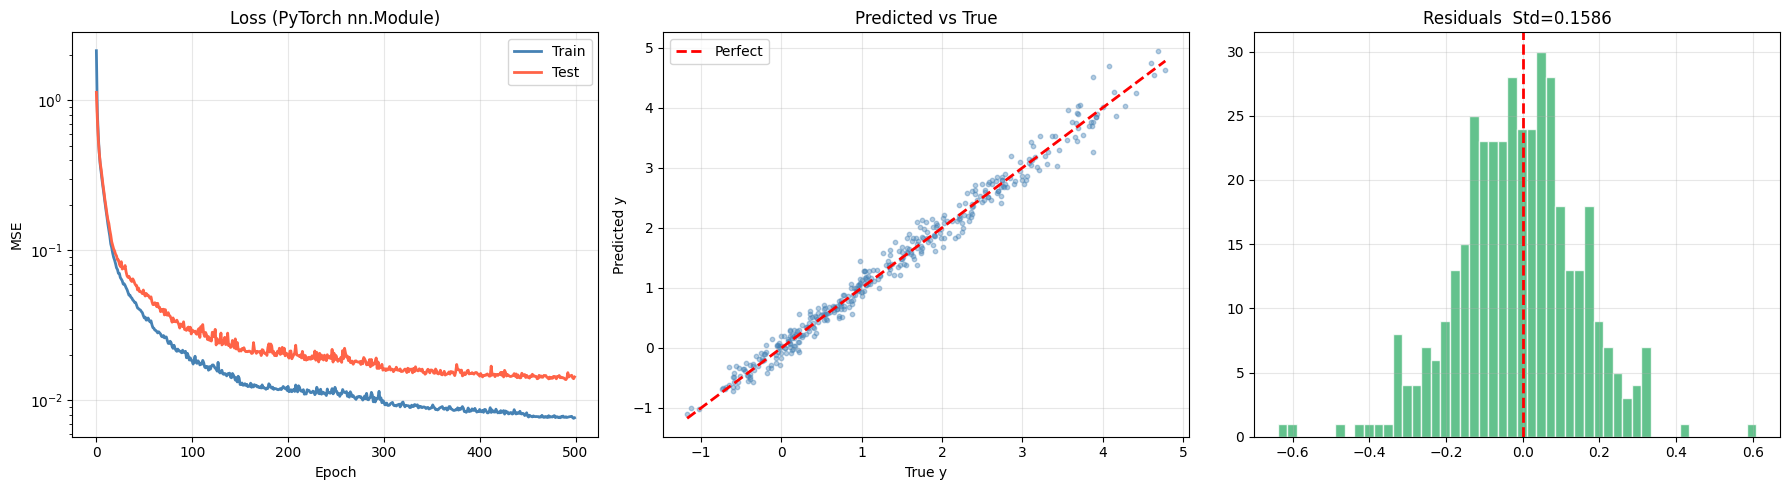

R²  : 0.9853
MAE : 0.1233
RMSE: 0.1591


In [5]:
# ─────────────────────────────────────────────
# SECTION 5: Results
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_losses, label='Train', color='steelblue', lw=2)
axes[0].plot(test_losses,  label='Test',  color='tomato',    lw=2)
axes[0].set_yscale('log'); axes[0].set_title('Loss (PyTorch nn.Module)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

model.eval()
X_test_t = torch.from_numpy(X_te).to(DEVICE)
with torch.no_grad():
    y_pred_np = model(X_test_t).cpu().numpy()

y_true_d = y_te * y_std + y_mean
y_pred_d = y_pred_np * y_std + y_mean

axes[1].scatter(y_true_d, y_pred_d, alpha=0.4, s=10, color='steelblue')
lims = [y_true_d.min(), y_true_d.max()]
axes[1].plot(lims, lims, 'r--', lw=2, label='Perfect')
axes[1].set_title('Predicted vs True'); axes[1].legend()
axes[1].set_xlabel('True y'); axes[1].set_ylabel('Predicted y')
axes[1].grid(True, alpha=0.3)

resid = (y_true_d - y_pred_d).ravel()
axes[2].hist(resid, bins=50, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', lw=2)
axes[2].set_title(f'Residuals  Std={resid.std():.4f}')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('colab_c_results.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'R²  : {r2_score(y_true_d, y_pred_d):.4f}')
print(f'MAE : {mean_absolute_error(y_true_d, y_pred_d):.4f}')
print(f'RMSE: {np.sqrt(np.mean(resid**2)):.4f}')